# 🔴 NephroScan AI v3 — Cancer / Not Cancer Detection

**Binary classification using existing v2 dataset:**
- **Cancer:** Tumour images (2,283)
- **Not Cancer:** Normal + Cyst + Stone (10,163)

Run cells top to bottom. Training ~1 hour on Apple MPS.

## Cell 1 — Imports & Setup

In [1]:
import os, sys, cv2, hashlib, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
print('Imports done')

# ── Paths ──────────────────────────────────────────────────────────────────
# Source: existing kidney_kaggle dataset
SRC_ROOT   = '/Users/devaguru/Kidney Stone CNN/kidney-stone-cnn/data/external/kidney_kaggle'
# Output: new v3 project
V3_ROOT    = '/Users/devaguru/Kidney Stone CNN/nephroscan-v3'
DATA_ROOT  = f'{V3_ROOT}/data/processed'
CHECKPOINT = f'{V3_ROOT}/checkpoints/best_model_v3.pth'

os.makedirs(f'{V3_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{V3_ROOT}/reports',     exist_ok=True)
for split in ['train','val','test']:
    for cls in ['cancer','not_cancer']:
        os.makedirs(f'{DATA_ROOT}/{split}/{cls}', exist_ok=True)

# ── Device ─────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# ── Config ─────────────────────────────────────────────────────────────────
# cancer=1, not_cancer=0
CANCER_CLASSES     = ['Tumor']                        # maps to cancer
NOT_CANCER_CLASSES = ['Normal', 'Cyst', 'Stone']      # maps to not_cancer
CLASS_NAMES        = ['not_cancer', 'cancer']
IMG_SIZE           = 224
BATCH_SIZE         = 8
EPOCHS             = 10
LR_HEAD            = 1e-3
LR_BACKBONE        = 1e-4
UNFREEZE_EPOCH     = 4
TEMPERATURE        = 0.5

print(f'Device:      {device}')
print(f'V3 Root:     {V3_ROOT}')
print(f'Cancer:      {CANCER_CLASSES}')
print(f'Not Cancer:  {NOT_CANCER_CLASSES}')
print('Ready ✅')

Imports done
Device:      mps
V3 Root:     /Users/devaguru/Kidney Stone CNN/nephroscan-v3
Cancer:      ['Tumor']
Not Cancer:  ['Normal', 'Cyst', 'Stone']
Ready ✅


## Cell 2 — Data Preprocessing & Split

In [2]:
def stable_hash(filename):
    h = int(hashlib.md5(filename.encode()).hexdigest(), 16)
    return (h % 10000) / 10000.0

def get_split(filename):
    v = stable_hash(filename)
    return 'train' if v < 0.70 else ('val' if v < 0.85 else 'test')

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge([l,a,b]), cv2.COLOR_LAB2BGR)

# Check if already done
already_done = all(
    len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg'))) > 0
    for split in ['train','val','test'] for cls in ['cancer','not_cancer']
)

stats = {s:{'cancer':0,'not_cancer':0} for s in ['train','val','test']}

if already_done:
    print('Already preprocessed — counting...')
    for split in ['train','val','test']:
        for cls in ['cancer','not_cancer']:
            stats[split][cls] = len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg')))
else:
    print('Preprocessing images...')

    # Cancer images — from Tumor folder
    for src_cls in CANCER_CLASSES:
        src_dir = Path(SRC_ROOT) / src_cls
        images  = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))
        print(f'  {src_cls} → cancer: {len(images)} images')
        for img_path in tqdm(images, desc=f'{src_cls}→cancer'):
            split = get_split(img_path.name)
            dst   = Path(DATA_ROOT) / split / 'cancer' / img_path.name
            if dst.exists(): continue
            img = cv2.imread(str(img_path))
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
            img = apply_clahe(img)
            cv2.imwrite(str(dst), img)
            stats[split]['cancer'] += 1

    # Not cancer images — from Normal, Cyst, Stone folders
    for src_cls in NOT_CANCER_CLASSES:
        src_dir = Path(SRC_ROOT) / src_cls
        images  = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))
        print(f'  {src_cls} → not_cancer: {len(images)} images')
        for img_path in tqdm(images, desc=f'{src_cls}→not_cancer'):
            split = get_split(img_path.name)
            dst   = Path(DATA_ROOT) / split / 'not_cancer' / img_path.name
            if dst.exists(): continue
            img = cv2.imread(str(img_path))
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
            img = apply_clahe(img)
            cv2.imwrite(str(dst), img)
            stats[split]['not_cancer'] += 1

print('\n=== DATASET SPLIT ===')
for split in ['train','val','test']:
    total = sum(stats[split].values())
    ratio = stats[split]['not_cancer'] / max(stats[split]['cancer'],1)
    print(f'[{split}] total={total} | cancer={stats[split]["cancer"]} | not_cancer={stats[split]["not_cancer"]} | ratio={ratio:.1f}:1')
print('Done ✅')

Preprocessing images...
  Tumor → cancer: 2283 images


Tumor→cancer:   0%|          | 0/2283 [00:00<?, ?it/s]

  Normal → not_cancer: 5077 images


Normal→not_cancer:   0%|          | 0/5077 [00:00<?, ?it/s]

  Cyst → not_cancer: 3709 images


Cyst→not_cancer:   0%|          | 0/3709 [00:00<?, ?it/s]

  Stone → not_cancer: 1377 images


Stone→not_cancer:   0%|          | 0/1377 [00:00<?, ?it/s]


=== DATASET SPLIT ===
[train] total=8650 | cancer=1533 | not_cancer=7117 | ratio=4.6:1
[val] total=1841 | cancer=358 | not_cancer=1483 | ratio=4.1:1
[test] total=1955 | cancer=392 | not_cancer=1563 | ratio=4.0:1
Done ✅


## Cell 3 — Verify Distribution

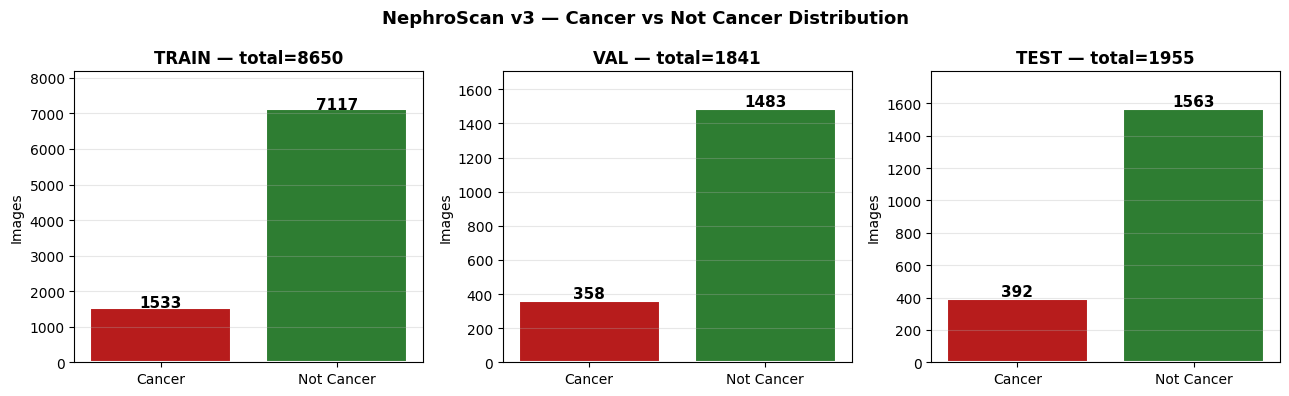

Imbalance is expected — WeightedRandomSampler will handle it during training


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('NephroScan v3 — Cancer vs Not Cancer Distribution', fontsize=13, fontweight='bold')
COLORS = {'cancer':'#B71C1C','not_cancer':'#2E7D32'}

for ax, split in zip(axes, ['train','val','test']):
    counts = [len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg')))
              for cls in ['cancer','not_cancer']]
    bars = ax.bar(['Cancer','Not Cancer'], counts,
                  color=['#B71C1C','#2E7D32'], edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(count),
                ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{split.upper()} — total={sum(counts)}', fontweight='bold')
    ax.set_ylabel('Images')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts)*1.15)

plt.tight_layout()
plt.savefig(f'{V3_ROOT}/reports/distribution_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imbalance is expected — WeightedRandomSampler will handle it during training')

## Cell 4 — Model, Dataset & Transforms

In [4]:
MEAN = [0.485,0.456,0.406]
STD  = [0.229,0.224,0.225]

def get_train_transforms():
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10,50), p=0.3),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

# ── Dataset ─────────────────────────────────────────────────────────────────
class CancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        # cancer=1, not_cancer=0
        for cls, label in [('cancer',1),('not_cancer',0)]:
            for p in (Path(root_dir)/cls).glob('*'):
                if p.suffix.lower() in ['.jpg','.jpeg','.png']:
                    self.samples.append((str(p), label))
        counts = Counter(s[1] for s in self.samples)
        print(f'[{Path(root_dir).name}] {len(self.samples)} images | cancer={counts[1]} | not_cancer={counts[0]}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform: img = self.transform(image=img)['image']
        return img, label

def get_weighted_sampler(dataset):
    labels  = [s[1] for s in dataset.samples]
    counts  = Counter(labels)
    weights = [1.0/counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

# ── Model — binary classifier ────────────────────────────────────────────────
class CancerClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=False, num_classes=0, global_pool='avg')
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, 2),   # binary: cancer vs not_cancer
        )
    def forward(self, x): return self.classifier(self.backbone(x))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

# ── Focal Loss ──────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        loss = ((1-torch.exp(-ce))**self.gamma)*ce
        return loss.mean()

# ── Build datasets ───────────────────────────────────────────────────────────
train_ds = CancerDataset(f'{DATA_ROOT}/train', get_train_transforms())
val_ds   = CancerDataset(f'{DATA_ROOT}/val',   get_val_transforms())
test_ds  = CancerDataset(f'{DATA_ROOT}/test',  get_val_transforms())

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=get_weighted_sampler(train_ds), num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Init model ───────────────────────────────────────────────────────────────
print('Building model...')
model     = CancerClassifier().to(device)
criterion = FocalLoss(gamma=2.0)

# Load backbone from v2 checkpoint for faster convergence
V2_CHECKPOINT = '/Users/devaguru/Kidney Stone CNN/nephroscan-v2/checkpoints/best_model_v2.pth'
if Path(V2_CHECKPOINT).exists():
    v2_state = torch.load(V2_CHECKPOINT, map_location=device)
    backbone_state = {k.replace('backbone.',''):v for k,v in v2_state.items() if k.startswith('backbone.')}
    model.backbone.load_state_dict(backbone_state, strict=False)
    print('Loaded backbone from v2 checkpoint ✅')
else:
    print('V2 checkpoint not found — training from scratch')

model.freeze_backbone()
optimizer = optim.AdamW(model.classifier.parameters(), lr=LR_HEAD)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print('Ready to train ✅')

[train] 8650 images | cancer=1533 | not_cancer=7117
[val] 1841 images | cancer=358 | not_cancer=1483
[test] 1955 images | cancer=392 | not_cancer=1563
Building model...
Loaded backbone from v2 checkpoint ✅
Parameters: 18,472,266
Ready to train ✅


## Cell 5 — Training Loop

In [6]:
history = {'epoch':[],'train_loss':[],'val_acc':[],'val_auc':[],'cancer_recall':[],'cancer_precision':[]}
best_val_auc = 0.0

print(f'Training {EPOCHS} epochs on {device}')
print(f'Backbone unfreezes at epoch {UNFREEZE_EPOCH}')
print('='*70)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_backbone()
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(),   'lr': LR_BACKBONE},
            {'params': model.classifier.parameters(), 'lr': LR_HEAD},
        ], weight_decay=1e-4)
        print(f'  >> Epoch {epoch}: backbone UNFROZEN')

    # Training
    model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_dl, desc=f'Epoch {epoch:02d} [train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_dl)

    # Validation
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_dl, desc=f'Epoch {epoch:02d} [val]  ', leave=False):
            logits = model(imgs.to(device))
            probs  = torch.softmax(logits/TEMPERATURE, dim=1)[:,1].cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    val_acc = (all_preds==all_labels).mean()
    auc     = roc_auc_score(all_labels, all_probs)
    report  = classification_report(all_labels, all_preds,
                  target_names=CLASS_NAMES, output_dict=True)
    cancer_rec  = report['cancer']['recall']
    cancer_prec = report['cancer']['precision']
    elapsed = time.time()-t0

    print(f'Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | acc={val_acc:.4f} | '
          f'auc={auc:.4f} | cancer_recall={cancer_rec:.4f} | cancer_precision={cancer_prec:.4f} | {elapsed:.0f}s')

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(auc)
    history['cancer_recall'].append(cancer_rec)
    history['cancer_precision'].append(cancer_prec)

    # Save best by AUC (more important than accuracy for cancer detection)
    if auc > best_val_auc:
        best_val_auc = auc
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  ✅ Best saved → AUC={auc:.4f}')

print('='*70)
print(f'Training complete. Best val AUC: {best_val_auc:.4f}')

Training 10 epochs on mps
Backbone unfreezes at epoch 4


Epoch 01 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

Epoch 01 [val]  :   0%|          | 0/231 [00:00<?, ?it/s]

Epoch 01/10 | loss=0.0848 | acc=0.9441 | auc=0.9983 | cancer_recall=0.9944 | cancer_precision=0.7790 | 159s
  ✅ Best saved → AUC=0.9983


Epoch 02 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

...

Epoch 06 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

Epoch 06 [val]  :   0%|          | 0/231 [00:00<?, ?it/s]

Epoch 06/10 | loss=0.0506 | acc=0.9962 | auc=1.0000 | cancer_recall=1.0000 | cancer_precision=0.9808 | 1304s
  ✅ Best saved → AUC=1.0000


Epoch 07 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Cell 6 — Training Curves

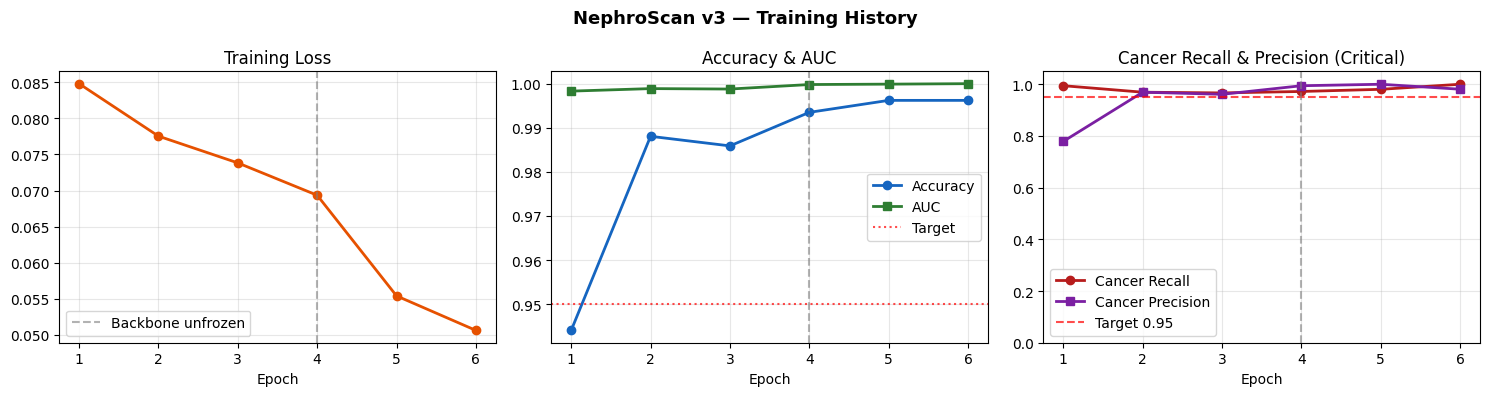

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('NephroScan v3 — Training History', fontsize=13, fontweight='bold')
epochs = history['epoch']

axes[0].plot(epochs, history['train_loss'], 'o-', color='#E65100', lw=2)
axes[0].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Backbone unfrozen')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'], 'o-', color='#1565C0', lw=2, label='Accuracy')
axes[1].plot(epochs, history['val_auc'], 's-', color='#2E7D32', lw=2, label='AUC')
axes[1].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6)
axes[1].axhline(0.95, color='red', linestyle=':', alpha=0.7, label='Target')
axes[1].set_title('Accuracy & AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['cancer_recall'],    'o-', color='#B71C1C', lw=2, label='Cancer Recall')
axes[2].plot(epochs, history['cancer_precision'], 's-', color='#7B1FA2', lw=2, label='Cancer Precision')
axes[2].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target 0.95')
axes[2].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('Cancer Recall & Precision (Critical)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_ylim(0,1.05)

plt.tight_layout()
plt.savefig(f'{V3_ROOT}/reports/training_curves_v3.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 7 — Test Set Evaluation

In [8]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f'Loaded best checkpoint: {CHECKPOINT}')

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_dl, desc='Test set'):
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits/TEMPERATURE, dim=1)[:,1].cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds==all_labels).mean()
auc      = roc_auc_score(all_labels, all_probs)
report   = classification_report(all_labels, all_preds,
               target_names=CLASS_NAMES, output_dict=True)

cancer_recall = report['cancer']['recall']
cancer_prec   = report['cancer']['precision']
specificity   = report['not_cancer']['recall']

print('='*60)
print('  TEST SET RESULTS — NephroScan v3 Cancer Detector')
print('='*60)
print(f'  Accuracy:          {accuracy:.4f}')
print(f'  AUC-ROC:           {auc:.4f}')
print('-'*60)
print(f'  Cancer Recall:     {cancer_recall:.4f}  {"✅" if cancer_recall>=0.95 else "⚠️  Below 0.95 target"}')
print(f'  Cancer Precision:  {cancer_prec:.4f}')
print(f'  Specificity:       {specificity:.4f}  (correctly identified not-cancer)')
print('-'*60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))
print('='*60)

Loaded best checkpoint: /Users/devaguru/Kidney Stone CNN/nephroscan-v3/checkpoints/best_model_v3.pth


Test set:   0%|          | 0/245 [00:00<?, ?it/s]

  TEST SET RESULTS — NephroScan v3 Cancer Detector
  Accuracy:          0.9918
  AUC-ROC:           1.0000
------------------------------------------------------------
  Cancer Recall:     1.0000  ✅
  Cancer Precision:  0.9608
  Specificity:       0.9898  (correctly identified not-cancer)
------------------------------------------------------------
              precision    recall  f1-score   support

  not_cancer     1.0000    0.9898    0.9949      1563
      cancer     0.9608    1.0000    0.9800       392

    accuracy                         0.9918      1955
   macro avg     0.9804    0.9949    0.9874      1955
weighted avg     0.9921    0.9918    0.9919      1955



## Cell 8 — ROC Curve & Confusion Matrix

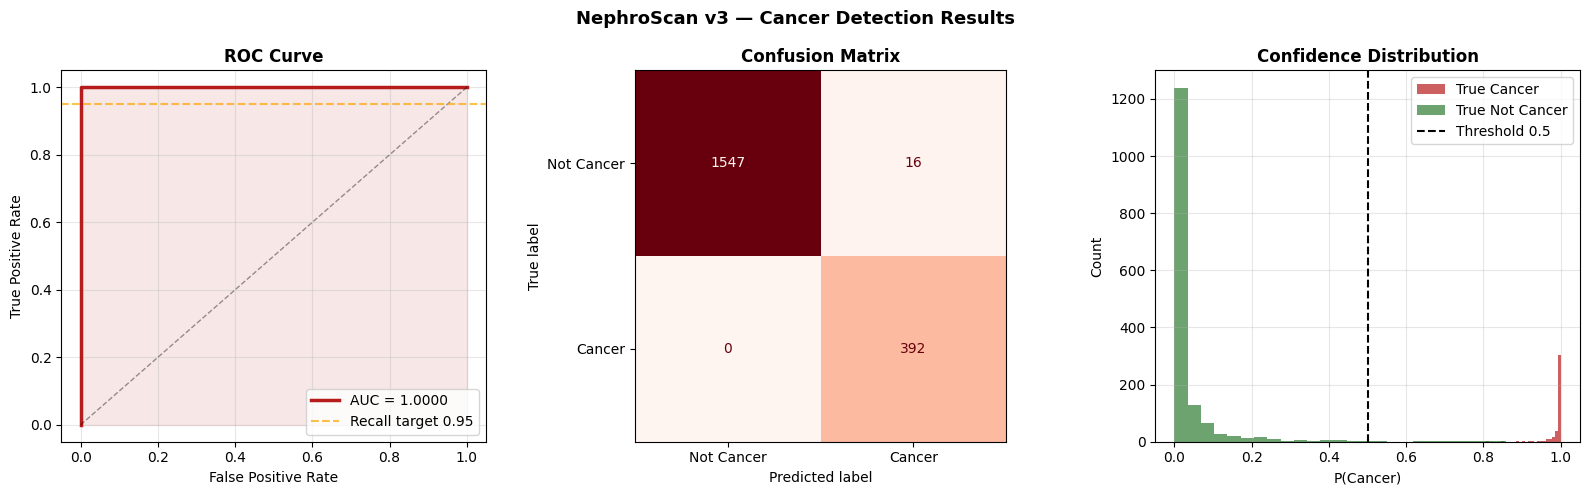

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('NephroScan v3 — Cancer Detection Results', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='#B71C1C', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].axhline(0.95, color='orange', linestyle='--', alpha=0.7, label='Recall target 0.95')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#B71C1C')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Not Cancer','Cancer']).plot(
    ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title('Confusion Matrix', fontweight='bold')

# Confidence Distribution
axes[2].hist(all_probs[all_labels==1], bins=25, alpha=0.7, color='#B71C1C', label='True Cancer')
axes[2].hist(all_probs[all_labels==0], bins=25, alpha=0.7, color='#2E7D32', label='True Not Cancer')
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold 0.5')
axes[2].set_xlabel('P(Cancer)'); axes[2].set_ylabel('Count')
axes[2].set_title('Confidence Distribution', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{V3_ROOT}/reports/evaluation_v3.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 9 — Predict Any Image

--- Tumour image (should be CANCER) ---


/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_48192/3395735901.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_48192/3395735901.py:29: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from current font.
  plt.tight_layout()
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


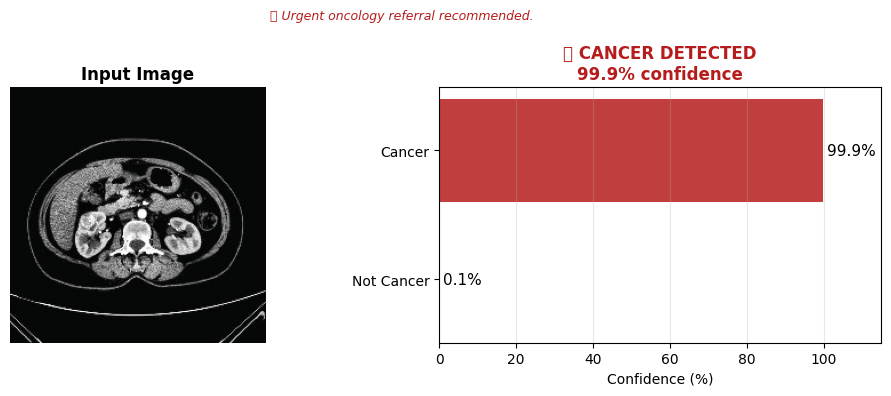

{'cancer': True, 'cancer_probability': 0.9991, 'not_cancer_probability': 0.0009}
--- Normal image (should be NOT CANCER) ---


/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_48192/3395735901.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


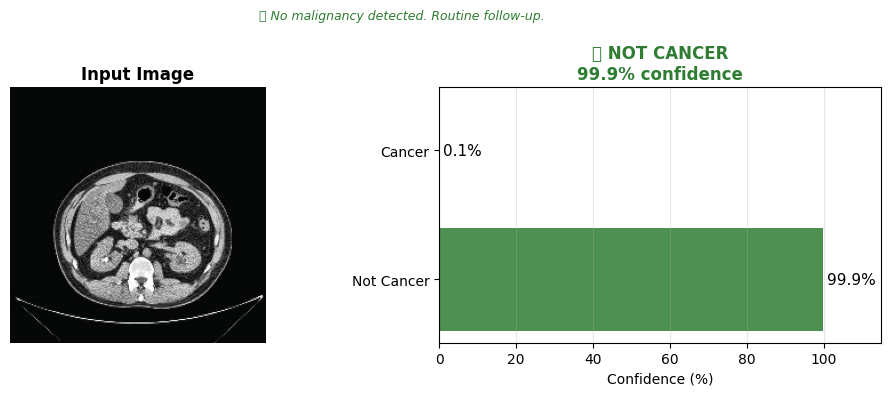

{'cancer': False, 'cancer_probability': 0.0009, 'not_cancer_probability': 0.9991}


In [10]:
def predict_cancer(image_path: str):
    img    = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    tensor = get_val_transforms()(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits/TEMPERATURE, dim=1)[0].cpu().numpy()
    cancer_prob    = probs[1]
    not_cancer_prob= probs[0]
    is_cancer      = cancer_prob >= 0.5

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    axes[0].imshow(img); axes[0].axis('off')
    axes[0].set_title('Input Image', fontweight='bold')

    color = '#B71C1C' if is_cancer else '#2E7D32'
    label = '🔴 CANCER DETECTED' if is_cancer else '🟢 NOT CANCER'
    bars  = axes[1].barh(['Not Cancer','Cancer'], [not_cancer_prob*100, cancer_prob*100],
                          color=['#2E7D32','#B71C1C'], alpha=0.85)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 115)
    axes[1].set_title(f'{label}\n{max(cancer_prob,not_cancer_prob):.1%} confidence',
                      fontweight='bold', color=color)
    for bar, prob in zip(bars, [not_cancer_prob, cancer_prob]):
        axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                     f'{prob:.1%}', va='center', fontsize=11)
    axes[1].grid(axis='x', alpha=0.3)
    note = 'Urgent oncology referral recommended.' if is_cancer else 'No malignancy detected. Routine follow-up.'
    plt.suptitle(f'📋 {note}', fontsize=9, style='italic', color=color)
    plt.tight_layout()
    plt.show()
    return {'cancer': is_cancer, 'cancer_probability': round(float(cancer_prob),4),
            'not_cancer_probability': round(float(not_cancer_prob),4)}

# Test on a tumour image
test_cancer = list(Path(f'{DATA_ROOT}/test/cancer').glob('*.jpg'))
test_normal = list(Path(f'{DATA_ROOT}/test/not_cancer').glob('*.jpg'))

if test_cancer:
    print('--- Tumour image (should be CANCER) ---')
    print(predict_cancer(str(test_cancer[0])))

if test_normal:
    print('--- Normal image (should be NOT CANCER) ---')
    print(predict_cancer(str(test_normal[0])))